In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Simple look into the Data

In [3]:
df.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

Having no nulls is great, but kind of rare. Dont skip cleaning. 

In [5]:
print(df.apply(lambda col: col.unique()).to_dict())

{'customerID': array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
       '8361-LTMKD', '3186-AJIEK'], dtype=object), 'gender': array(['Female', 'Male'], dtype=object), 'SeniorCitizen': array([0, 1]), 'Partner': array(['Yes', 'No'], dtype=object), 'Dependents': array(['No', 'Yes'], dtype=object), 'tenure': array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39]), 'PhoneService': array(['No', 'Yes'], dtype=object), 'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object), 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object), 'OnlineSecurity': array(['No', 'Yes', 'No internet service'], dtype=object), 'OnlineBackup': array(['Yes', 'No', 'No internet service'], dtype=object), 

Above was to see if all of the data was standardized. By this I mean making sure there was not more than one way to say the same answer (ex: YES, Yes, and yes are all different ways to say the same thing)

In [6]:
df = df.drop(['customerID'], axis = 1)

In [7]:
# Drop duplicate rows across all columns
df_cleaned = df.drop_duplicates()

In [8]:
df_cleaned["TotalCharges"] = pd.to_numeric(
    df_cleaned["TotalCharges"],
    errors="coerce"
)

/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_34586/4088732173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["TotalCharges"] = pd.to_numeric(


In [9]:
df_cleaned.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df_cleaned[df_cleaned["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Here we can see where the toal charges are NaN, the tenure is also 0. That just shows that they customers there are just signed up and so you have changes. Here we will change the NaN to 0.

In [11]:
df_cleaned["TotalCharges"] = df_cleaned["TotalCharges"].fillna(0)

/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_34586/3449329307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["TotalCharges"] = df_cleaned["TotalCharges"].fillna(0)


In [12]:
# just to check
df_cleaned["TotalCharges"].isnull().sum()

0

I want to look at the data a little more before changing anything else. 
Lets first look at the churn rate

In [13]:
mem_left = (df_cleaned["Churn"] == "Yes").sum()
mem_stay = (df_cleaned["Churn"] == "No").sum()

total_customers = mem_left + mem_stay

churn_percent = mem_left / total_customers
stay_percent = mem_stay / total_customers


In [14]:
print(f"Customers who stayed: {mem_stay}")
print(f"Customers who churned: {mem_left}")

print(f"\nRetention Rate: {stay_percent:.2%}")
print(f"Churn Rate: {churn_percent:.2%}")

Customers who stayed: 5164
Customers who churned: 1857

Retention Rate: 73.55%
Churn Rate: 26.45%


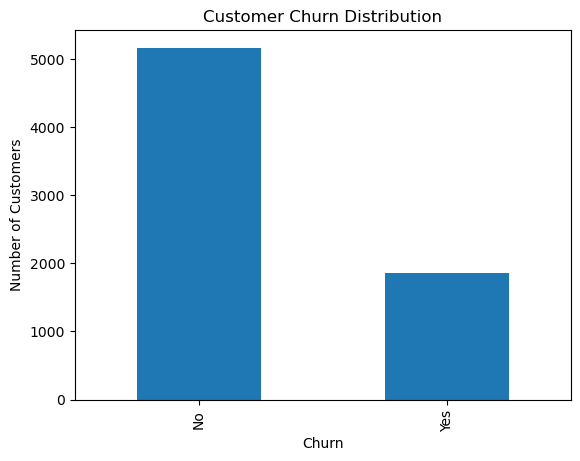

In [15]:
df_cleaned["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Approximately 26.45% of customers left the company while 73.55% remained. This indicates that the dataset is moderately imbalanced, with more customers staying than leaving. This imbalance should be considered later when evaluating classification models, as accuracy alone may not provide a complete picture of model performance.

In [16]:
df_cleaned[['TotalCharges', 'MonthlyCharges', 'tenure']].describe()

,TotalCharges,MonthlyCharges,tenure
count,7021.000000,7021.000000,7021.000000
mean,2286.765026,64.851894,32.469449
std,2266.855057,30.069001,24.534965
min,0.000000,18.250000,0.000000
25%,403.350000,35.750000,9.000000
50%,1400.550000,70.400000,29.000000
75%,3801.700000,89.900000,55.000000
max,8684.800000,118.750000,72.000000


In [17]:
cat_cols = df_cleaned.select_dtypes(include="object").columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [18]:
for col in cat_cols:
    print("\n", col)
    print(df_cleaned[col].value_counts())


 gender
gender
Male      3541
Female    3480
Name: count, dtype: int64

 Partner
Partner
No     3619
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4911
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6339
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3368
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3090
DSL            2419
No             1512
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3490
Yes                    2019
No internet service    1512
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3080
Yes                    2429
No internet service    1512
Name: count, dtype: int64

 DeviceProtection
DeviceProtection
No                     3087
Yes                    2422
No internet service    1512
Name: count, dtype: int64

 TechSupport
TechSupport
No   

In [19]:
for col in cat_cols:
    print("\n", col)
    print(df_cleaned[col].value_counts(normalize=True))


 gender
gender
Male      0.504344
Female    0.495656
Name: proportion, dtype: float64

 Partner
Partner
No     0.515454
Yes    0.484546
Name: proportion, dtype: float64

 Dependents
Dependents
No     0.699473
Yes    0.300527
Name: proportion, dtype: float64

 PhoneService
PhoneService
Yes    0.902863
No     0.097137
Name: proportion, dtype: float64

 MultipleLines
MultipleLines
No                  0.479704
Yes                 0.423159
No phone service    0.097137
Name: proportion, dtype: float64

 InternetService
InternetService
Fiber optic    0.440108
DSL            0.344538
No             0.215354
Name: proportion, dtype: float64

 OnlineSecurity
OnlineSecurity
No                     0.497080
Yes                    0.287566
No internet service    0.215354
Name: proportion, dtype: float64

 OnlineBackup
OnlineBackup
No                     0.438684
Yes                    0.345962
No internet service    0.215354
Name: proportion, dtype: float64

 DeviceProtection
DeviceProtection
No   

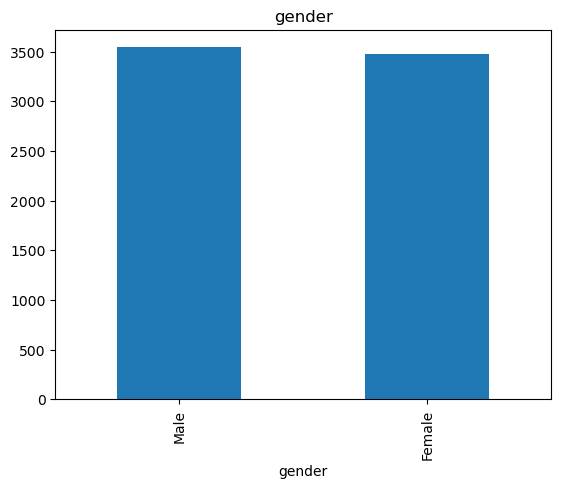

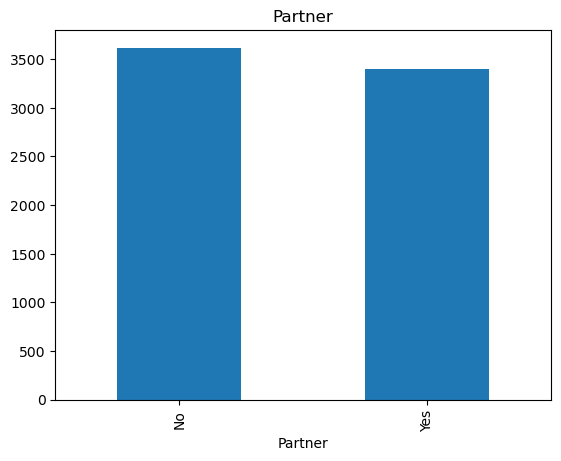

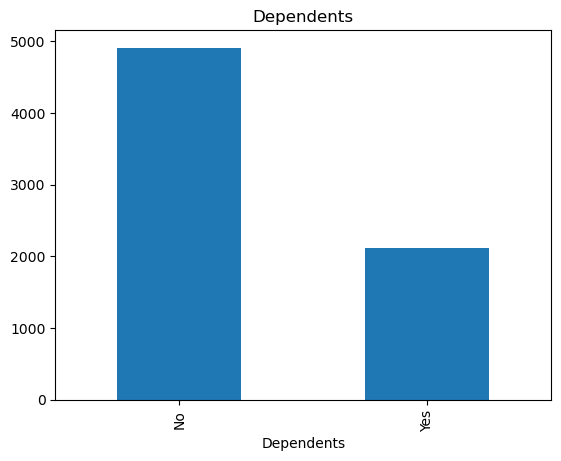

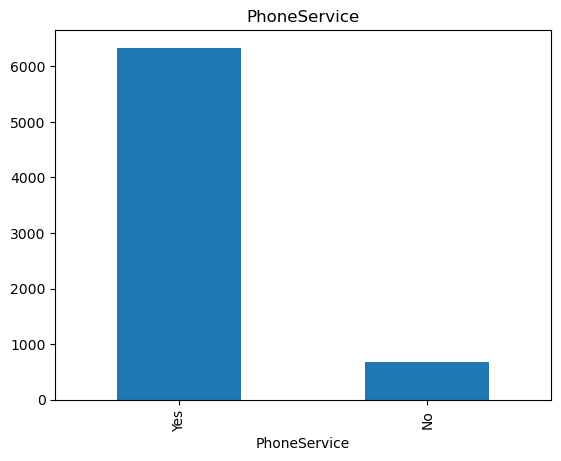

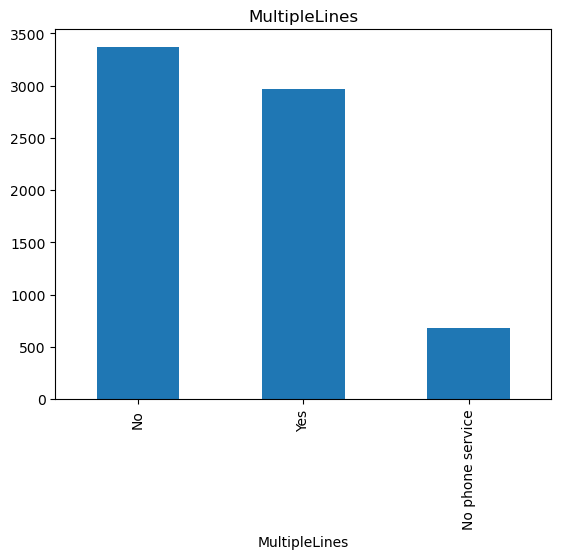

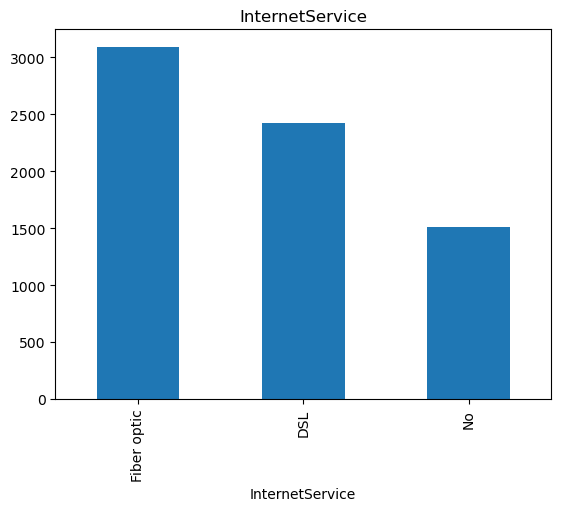

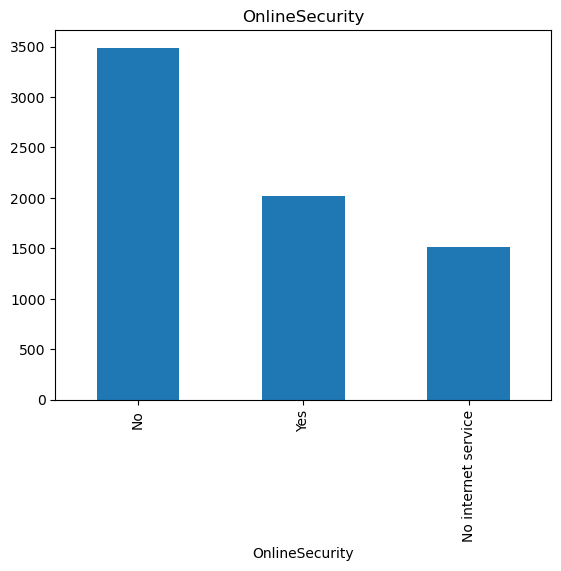

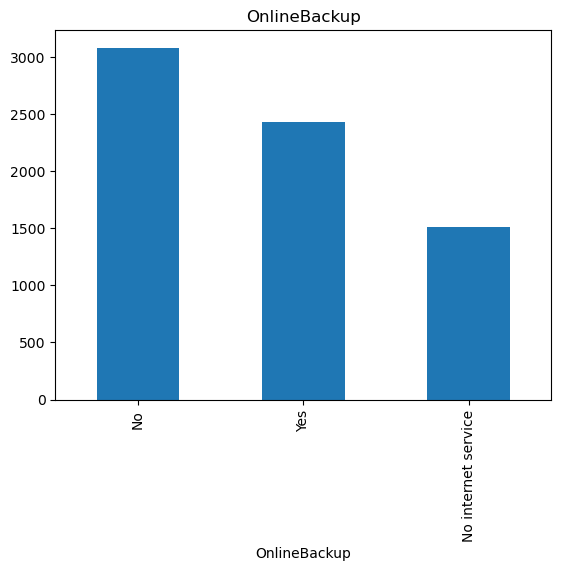

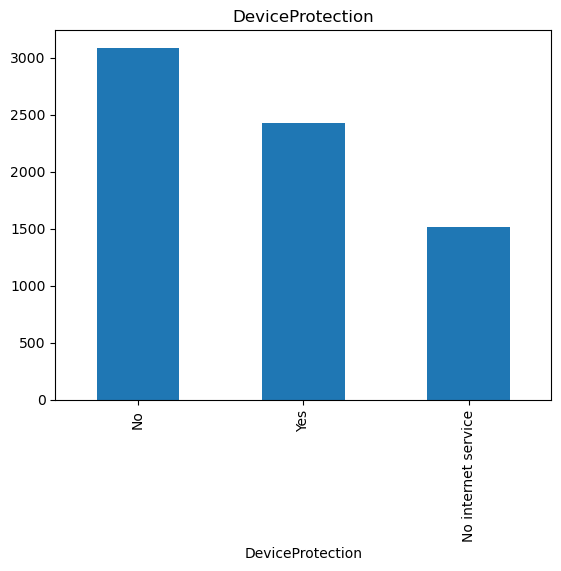

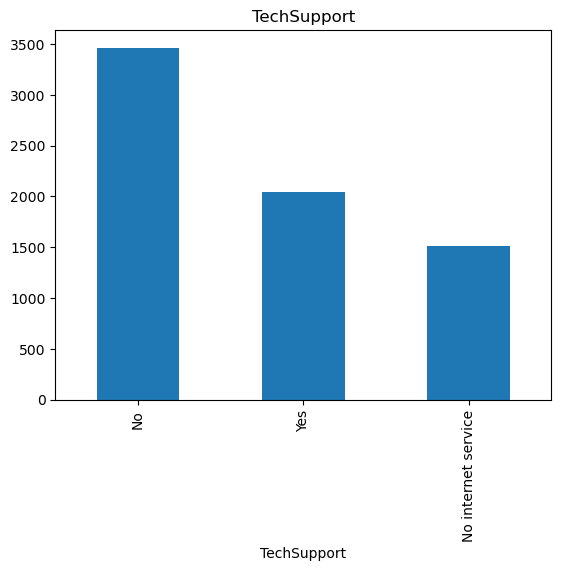

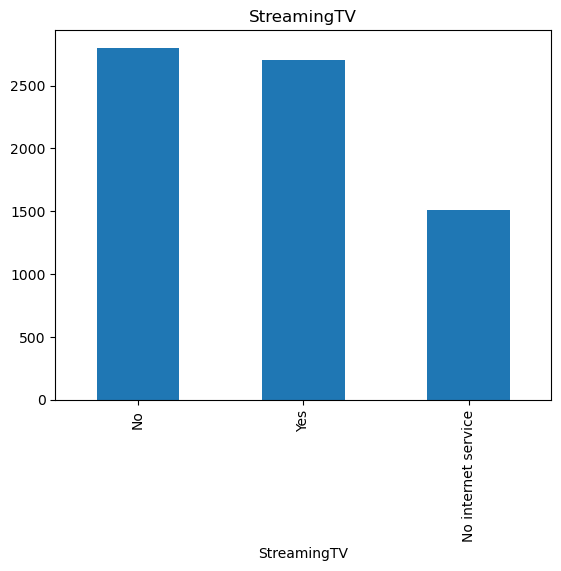

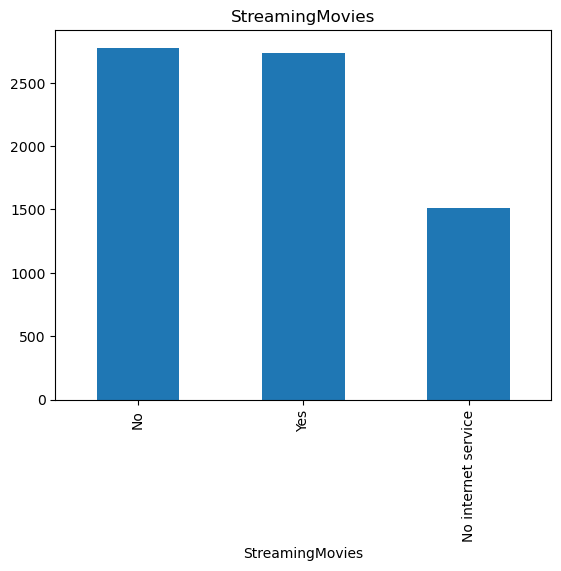

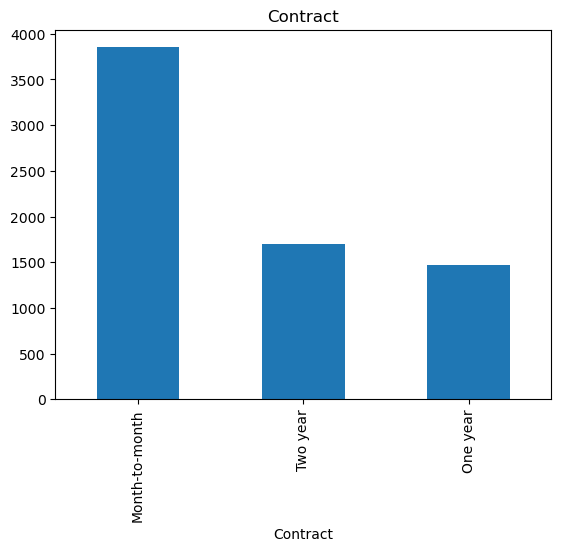

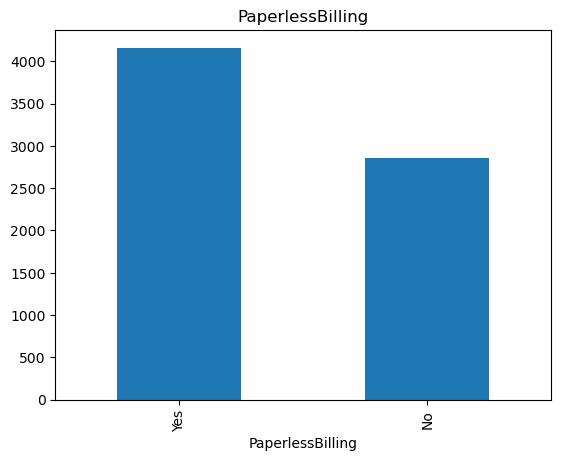

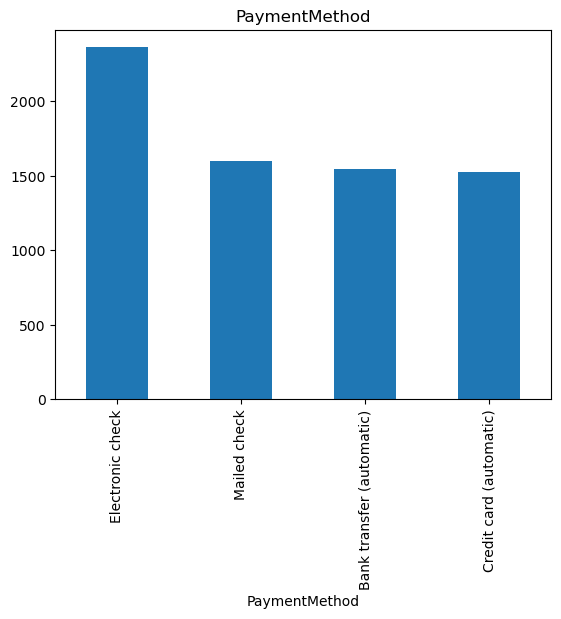

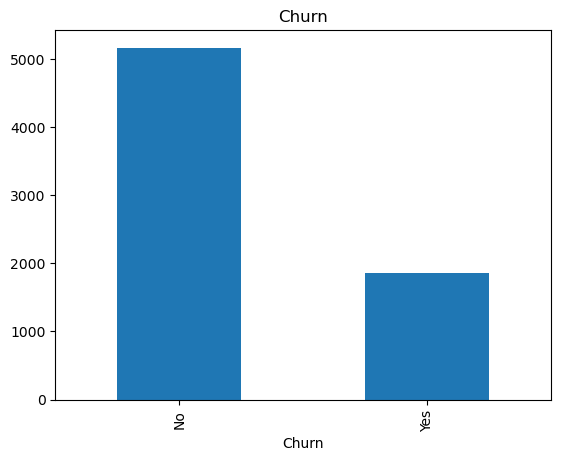

In [20]:
for col in cat_cols:
    df_cleaned[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()
# this is all in one print out cell, i would just suggest scrolling down

In [21]:
# does this affect the churn rate?
for col in cat_cols:
    if col != "Churn":
        print("\n", col)
        print(pd.crosstab(df_cleaned[col], df_cleaned["Churn"], normalize="index"))


 gender
Churn         No       Yes
gender                    
Female  0.731609  0.268391
Male    0.739339  0.260661

 Partner
Churn          No       Yes
Partner                    
No       0.671733  0.328267
Yes      0.803351  0.196649

 Dependents
Churn             No       Yes
Dependents                    
No          0.688251  0.311749
Yes         0.845498  0.154502

 PhoneService
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.733870  0.266130

 MultipleLines
Churn                   No       Yes
MultipleLines                       
No                0.751485  0.248515
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

 InternetService
Churn                  No       Yes
InternetService                    
DSL              0.811079  0.188921
Fiber optic      0.582201  0.417799
No               0.927910  0.072090

 OnlineSecurity
Churn                      No       Yes
OnlineSecurity       

In [22]:
cat_cols = df_cleaned.select_dtypes(include="object").columns
cat_cols = [col for col in cat_cols if col != "Churn"]

chi_results = {}

for col in cat_cols:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    chi_results[col] = p

sorted(chi_results.items(), key=lambda x: x[1])

[('Contract', 6.442284610021268e-257),
 ('OnlineSecurity', 1.329226523787891e-184),
 ('TechSupport', 7.146857715828324e-180),
 ('InternetService', 1.0857790034735195e-159),
 ('PaymentMethod', 3.0267752570875056e-139),
 ('OnlineBackup', 8.614898409283198e-131),
 ('DeviceProtection', 1.9555513236078665e-121),
 ('StreamingMovies', 2.750289622934079e-82),
 ('StreamingTV', 5.469454144000632e-82),
 ('PaperlessBilling', 2.1518977990247168e-57),
 ('Dependents', 1.5995676694072134e-42),
 ('Partner', 1.0999615978939857e-35),
 ('MultipleLines', 0.0020685599531309134),
 ('PhoneService', 0.3664940064978197),
 ('gender', 0.4794615390898278)]

Looking above shows how much each column has a statistically significant impact on the churn rate. 
From that we can see what features show statistically significant relationships with churn (p < 0.05), with the strongest associations observed in Contract, InternetService, and OnlineSecurity. However, PhoneService and gender do not show evidence of a meaningful relationship with churn.. 

# Data Manipulation

In [23]:
X = df_cleaned.drop("Churn", axis=1)
y = df_cleaned["Churn"].map({"No": 0, "Yes": 1})

In [24]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [25]:
binary_map = {
    "Yes": 1,
    "No": 0
}

binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    X[col] = X[col].map(binary_map)

In [26]:
X["gender"] = X["gender"].map({"Female": 0, "Male": 1})

In [27]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [28]:
X.shape
X.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [29]:
print(df_cleaned["TotalCharges"].dtype)

print(df_cleaned["TotalCharges"].head())

print(df_cleaned["TotalCharges"].isna().sum())

print(df_cleaned[["TotalCharges", "MonthlyCharges", "tenure"]].dtypes)

float64
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64
0
TotalCharges      float64
MonthlyCharges    float64
tenure              int64
dtype: object


# Predictive Analysis, the First Phase
Here I willuse logistic regression to see how a predictive analysis would preform with this data. 

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



In [33]:
y_proba = model.predict_proba(X_test)[:, 1]

y_pred_custom = (y_proba > 0.3).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.55      0.70      1033
           1       0.43      0.94      0.59       372

    accuracy                           0.65      1405
   macro avg       0.70      0.74      0.64      1405
weighted avg       0.82      0.65      0.67      1405



In [34]:
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (y_proba > t).astype(int)
    print(t, f1_score(y_test, preds))

0.1 0.5010211027910143
0.15000000000000002 0.5272331154684096
0.20000000000000004 0.5497702909647779
0.25000000000000006 0.5705076551168412
0.30000000000000004 0.5882352941176471
0.3500000000000001 0.5959328028293546
0.40000000000000013 0.6062322946175638
0.45000000000000007 0.6049751243781094
0.5000000000000001 0.6129374337221634
0.5500000000000002 0.6206115515288788
0.6000000000000002 0.6081730769230769
0.6500000000000001 0.6020671834625323
0.7000000000000002 0.5835694050991501
0.7500000000000002 0.5837173579109063
0.8000000000000002 0.4868651488616462
0.8500000000000002 0.3128964059196617


Above shows how the number of thresh holds will affect the f-1 score. 
The optimal classification threshold was found to be approximately 0.55, which maximized the F1-score for churn prediction. This indicates that adjusting the decision boundary improves the balance between precision and recall compared to the default threshold of 0.5.

# Logistic Regression 

In [35]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients

,Feature,Coefficient
8,MultipleLines_No phone service,0.518997
10,InternetService_Fiber optic,0.466805
28,PaymentMethod_Electronic check,0.336716
26,PaperlessBilling_1,0.329078
0,SeniorCitizen,0.246444
9,MultipleLines_Yes,0.173364
23,StreamingMovies_Yes,0.084206
21,StreamingTV_Yes,0.049903
4,gender_1,0.027003
2,MonthlyCharges,0.012713


Everything that has a positive coeffienect means a increased churn risk.The negative coeffienect means a decresed churn risk.

In [36]:
coefficients.head(10)
coefficients.tail(10)

,Feature,Coefficient
11,InternetService_No,-0.064536
27,PaymentMethod_Credit card (automatic),-0.072140
17,DeviceProtection_Yes,-0.107202
6,Dependents_1,-0.178778
15,OnlineBackup_Yes,-0.186661
19,TechSupport_Yes,-0.348673
7,PhoneService_1,-0.370279
13,OnlineSecurity_Yes,-0.414571
24,Contract_One year,-0.692992
25,Contract_Two year,-1.423541


In [37]:
coefficients["abs_coef"] = coefficients["Coefficient"].abs()
coefficients.sort_values("abs_coef", ascending=False).head(15)

,Feature,Coefficient,abs_coef
25,Contract_Two year,-1.423541,1.423541
24,Contract_One year,-0.692992,0.692992
8,MultipleLines_No phone service,0.518997,0.518997
10,InternetService_Fiber optic,0.466805,0.466805
13,OnlineSecurity_Yes,-0.414571,0.414571
7,PhoneService_1,-0.370279,0.370279
19,TechSupport_Yes,-0.348673,0.348673
28,PaymentMethod_Electronic check,0.336716,0.336716
26,PaperlessBilling_1,0.329078,0.329078
0,SeniorCitizen,0.246444,0.246444


This above shows how different features can influence churn rate, if the coefficient is negative then it corresponds with a lower churn rate. For example, both one and two year contracts ass well as good tech support, security, and having an online backup are all negative coefficients, therefore they show a lesser churn rate. On the other hand, features like no phone service, fiber opitc service, an electric check, having multiple lines, and if the customer is a senior citizen can add the the churn rate. 

In [38]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values("Coefficient", ascending=False)

coefficients.head(15)

,Feature,Coefficient
8,MultipleLines_No phone service,0.518997
10,InternetService_Fiber optic,0.466805
28,PaymentMethod_Electronic check,0.336716
26,PaperlessBilling_1,0.329078
0,SeniorCitizen,0.246444
9,MultipleLines_Yes,0.173364
23,StreamingMovies_Yes,0.084206
21,StreamingTV_Yes,0.049903
4,gender_1,0.027003
2,MonthlyCharges,0.012713


In [39]:
coefficients.tail(15)

,Feature,Coefficient
16,DeviceProtection_No internet service,-0.064536
18,TechSupport_No internet service,-0.064536
20,StreamingTV_No internet service,-0.064536
12,OnlineSecurity_No internet service,-0.064536
22,StreamingMovies_No internet service,-0.064536
11,InternetService_No,-0.064536
27,PaymentMethod_Credit card (automatic),-0.072140
17,DeviceProtection_Yes,-0.107202
6,Dependents_1,-0.178778
15,OnlineBackup_Yes,-0.186661


The had and tail of the coefficients above show the coefficients in order for highest to smallest. There are several important things that can be seen here, but one to mentioni right off the bat is the multicollinearity of this data, that means that two or more independent variables are closely tied.

# Biggest Churn Rate Drivers
- MultipleLines_No phone service (interpret cautiously because of multicollinearity)
- InternetService_Fiber optic
- PaymentMethod_Electronic check
- PaperlessBilling
- Senior Citizen

# Biggest Rentintino Factors
- Contract_Two year (with a coeffient of -1.42, this is the strongest retention factor)
- Contract_One year
- OnlineSecurity
- TechSupport_Yes
- PhoneService_1 (the chi-square test suggested PhoneService wasn't significant on its own. Interpret with caution)
- OnlineBackup


# What does that mean?
Customers on two-year contracts are much less likely to churn than customers on the baseline contract type. Since a one year contract is the second lowest coefficient this shows that a longer commitment is correlated to a lower churn rate. 
From this we can also see that customers receiving technical support are substantially less likely to churn, which can be then be seen as investing in customer support may improve retention. If a customer is purchasing additional services tend to remain customers longer. 